## Carregando os dados de treino
As análises serão feitas apenas no dataset de treino, já que as decisões de projeto devem ser tomadas tendo ele como base

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
BASE_DIR = '../data'
TRAIN_CSV_PATH = os.path.join(BASE_DIR, 'train.csv')

df_train = pd.read_csv(TRAIN_CSV_PATH)

In [3]:
print(f"Tamanho do dataset de treino: {df_train.shape}")

Tamanho do dataset de treino: (106800, 15)


In [4]:
display(df_train.head())

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0


In [5]:
vote_cols = ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']
df_train['total_vote'] = df_train[vote_cols].sum(axis=1)

## Consenso

In [6]:
probs_df = df_train[vote_cols].div(df_train['total_vote'], axis=0)
probs_df['expert_consensus'] = df_train['expert_consensus']
comparacao_votos = probs_df.groupby('expert_consensus')[vote_cols].mean()

Tabela de Comparação de Votos:
                  seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
expert_consensus                                                           
GPD                   0.085323  0.051580  0.733302   0.005764   0.031950   
GRDA                  0.003610  0.008394  0.015776   0.030613   0.860915   
LPD                   0.028486  0.762575  0.030462   0.065302   0.009407   
LRDA                  0.012363  0.043073  0.005960   0.731774   0.063854   
Other                 0.013517  0.041977  0.024428   0.047195   0.060107   
Seizure               0.949322  0.012207  0.008170   0.006102   0.002123   

                  other_vote  
expert_consensus              
GPD                 0.092082  
GRDA                0.080691  
LPD                 0.103768  
LRDA                0.142977  
Other               0.812776  
Seizure             0.022076  


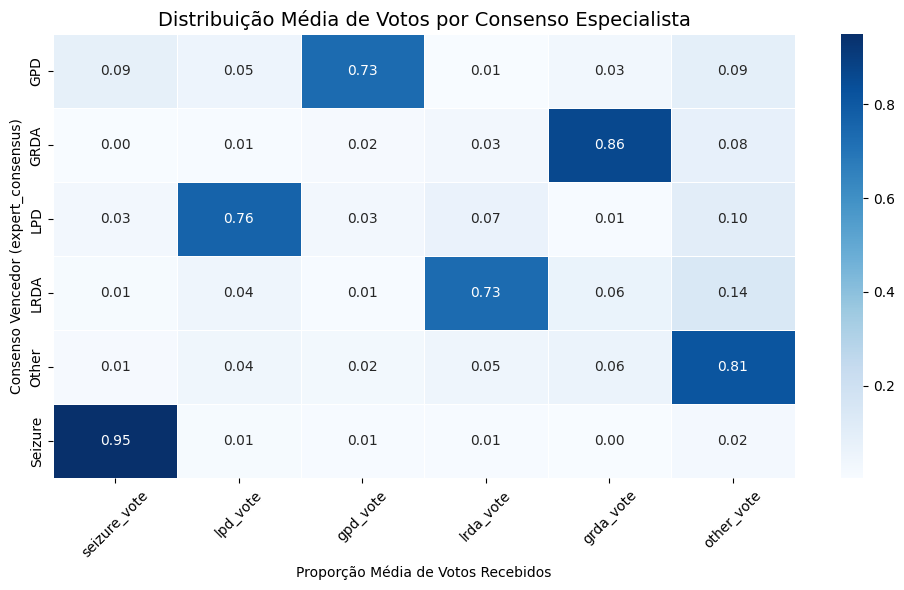

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(comparacao_votos, annot=True, cmap='Blues', fmt=".2f", linewidths=.5)
plt.title('Distribuição Média de Votos por Consenso Especialista', fontsize=14)
plt.ylabel('Consenso Vencedor (expert_consensus)')
plt.xlabel('Proporção Média de Votos Recebidos')
plt.xticks(rotation=45)
plt.tight_layout()

print("Tabela de Comparação de Votos:")
print(comparacao_votos)

Os diagnósticos mais difíceis de ter consenso parecem ser o de GPD e LRDA. Em ambos apenas 73% dos médicos votou no resultado final. No caso de GPD, 18% dos médicos acredita se tratar de uma Seizure ou outro diagnóstico. No caso de LRDA, 14% dos médicos crê em outro diagnóstico para a anomalia.

Os médicos parecem ter pouquíssima dificuldade em identificar uma Seizure

In [8]:
df_train['agreement'] = probs_df[vote_cols].max(axis=1) * 100
class_order = df_train.groupby('expert_consensus')['agreement'].mean().sort_values(ascending=False).index

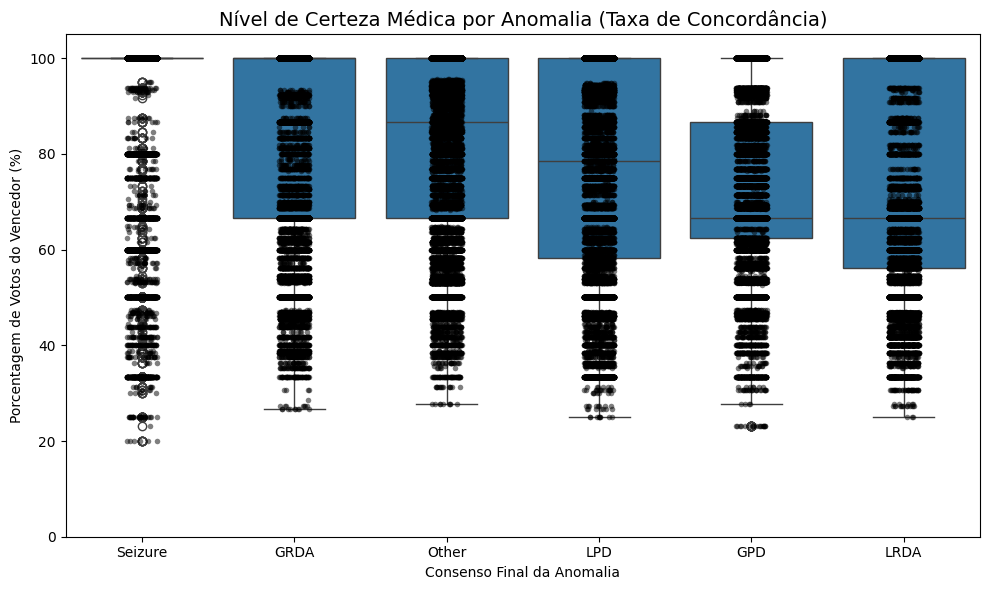

In [9]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_train, x='expert_consensus', y='agreement', order=class_order)
sns.stripplot(data=df_train, x='expert_consensus', y='agreement', order=class_order, color='black', alpha=0.5, size=4)

plt.title('Nível de Certeza Médica por Anomalia (Taxa de Concordância)', fontsize=14)
plt.ylabel('Porcentagem de Votos do Vencedor (%)')
plt.xlabel('Consenso Final da Anomalia')

plt.ylim(0, 105) 
plt.tight_layout()

plt.show()

In [10]:
print("Ranking de Certeza Médica (100% = Unanimidade / Menor = Mais Incerteza):")
ranking = df_train.groupby('expert_consensus')['agreement'].mean().sort_values(ascending=False)
print(ranking.round(1).astype(str) + "%")

Ranking de Certeza Médica (100% = Unanimidade / Menor = Mais Incerteza):
expert_consensus
Seizure    94.9%
GRDA       86.1%
Other      81.3%
LPD        76.3%
GPD        73.3%
LRDA       73.2%
Name: agreement, dtype: object


Esses últimos resultados parecem confirmar a hipótese inicial. Seizure realmente tem a maior unanimidade entre os votos médicos. 75% dos diagnósticos de Seizure foram unânimes.

Por outro lado, LPD, GPD e LRDA têm pelo menos 25% dos diagnósticos com menos de 60% de votos "certos". Além disso, os Whiskers de todas as caixas exceto Seizure vão até valores menores de 30% dos votos. Ou seja, para essas anomalias, se apenas 30% dos médicos acerta o diagnóstico ainda não é considerado um outlier

### O que isso significa?

É esperado que o modelo criado acerte mais os casos de Seizure, pois se tratando até de erro humano, essa anomalia contém menos incerteza.

Também são esperados mais erros relacionados as anomalias GPD, LRDA e até LPD, com diagnósticos trocados entre si ou com diagnóstico "outro"

## Correlação entre os votos de anomalias

In [11]:
def calc_p_value(df_votes):
    cols = df_votes.columns
    p_matrix = np.zeros((len(cols), len(cols)))

    for i, col1 in enumerate(cols):
        for j, col2 in enumerate(cols):
            _, p_val = pearsonr(df_votes[col1], df_votes[col2])
            p_matrix[i, j] = p_val
    return pd.DataFrame(p_matrix, index=cols, columns=cols)

In [12]:
brute_corr_matrix = df_train[vote_cols].corr()
p_value_matrix = calc_p_value(df_train[vote_cols])

In [13]:
notes = brute_corr_matrix.round(2).astype(str)

for i in range(len(brute_corr_matrix.columns)):
    for j in range(len(brute_corr_matrix.columns)):
        p_val = p_value_matrix.iloc[i, j]
        if p_val < 0.05 and i != j:
            notes.iloc[i, j] += '*'

Tabela de Correlação de Votos Brutos:
              seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
seizure_vote      1.000000 -0.126061  0.126841  -0.174617  -0.241683   
lpd_vote         -0.126061  1.000000 -0.059229   0.020348  -0.140632   
gpd_vote          0.126841 -0.059229  1.000000  -0.150559  -0.091000   
lrda_vote        -0.174617  0.020348 -0.150559   1.000000  -0.053259   
grda_vote        -0.241683 -0.140632 -0.091000  -0.053259   1.000000   
other_vote       -0.208527 -0.025377 -0.060530   0.074365   0.074807   

              other_vote  
seizure_vote   -0.208527  
lpd_vote       -0.025377  
gpd_vote       -0.060530  
lrda_vote       0.074365  
grda_vote       0.074807  
other_vote      1.000000  


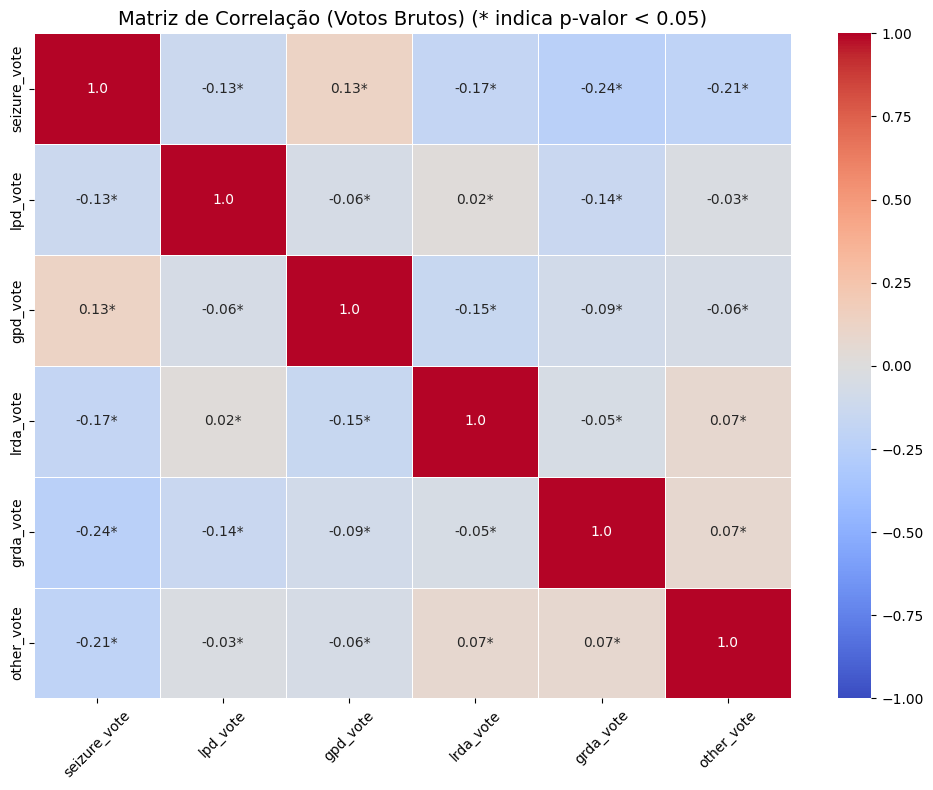

In [14]:
plt.figure(figsize=(10, 8))

sns.heatmap(brute_corr_matrix, annot=notes, cmap='coolwarm', center=0, 
            fmt="", linewidths=.5, vmin=-1, vmax=1)

plt.title('Matriz de Correlação (Votos Brutos) (* indica p-valor < 0.05)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()

print("Tabela de Correlação de Votos Brutos:")
print(brute_corr_matrix)

Analisando a matriz de correlações, é perceptível que a maior parte das relações entre as anomalias é baixa. A maior correlação positiva ocorre entre GPD e Seizure, mas ainda assim é uma correlação muito baixa. Apesar disso, ainda se tratando de Seizures, essa anomalia também tem as maiores correlações negativas, chegando a -0.24 em relação a GRDA.

Apesar de todas as correlações serem estatísticamente significantes, ainda são relações bem fracas e o resultado de significância pode estar sendo potencializado pelo tamanho da base.

Ainda assim, com exceção da relação Seizure x GPD, votos em Seizure geralmente representam menos votos em outras anomalias. Fortalecendo o argumento do padrão-ouro de Seizure